In [62]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [63]:
def print_multiple(run_dirs, labels, title="comparison"):
    """
    run_dirs: пути к папкам
    labels: подписи (["SignMuon", "Adam", "SGD"])
    metric: что выдаем ("iters_to_converge", "final_loss", )
    """
    print(title)

    for run_dir, label in zip(run_dirs, labels):
        run_dir = Path(run_dir)

        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)

        iters_to_converge = data["iters_to_converge"]
        final_loss = data["final_loss"]


        print(label)
        print("iters_to_converge:", iters_to_converge)
        print(f"final_loss: {final_loss:.4f}")
        print('\n')

In [64]:

def plot_multiple_histories(run_dirs, labels, metric="train_loss", title="comparison", 
                            target_loss=None, max_iterations=None, line_styles=None):
    """
    run_dirs: пути к папкам
    labels: подписи (["SignMuon", "Adam", "SGD"])
    metric: что рисуем ("loss_history", "grad_norm_history", "train_loss")
    target_loss: пороговое значение потерь (например, 0.001) - графики обрезаются до достижения этого значения
    max_iterations: максимальное количество итераций для отображения (если None, берется из данных)
    line_styles: список стилей линий для каждого графика (например, ["-", "--", "-.", ":", "-"])
                 если None, то все сплошные
    """
    
    plt.figure(figsize=(8, 6))
    
    if line_styles is None:
        line_styles = ["-"] * len(run_dirs)
    
    max_len = 0
    all_histories = []
    
    for run_dir in run_dirs:
        run_dir = Path(run_dir)
        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)
        values = np.array(data[metric])
        all_histories.append(values)
        max_len = max(max_len, len(values))
    
    for i, (run_dir, label, history, line_style) in enumerate(zip(run_dirs, labels, all_histories, line_styles)):
        values = history.copy()
        
        if target_loss is not None and metric in ["loss_history", "train_loss", "val_loss"]:
            mask = values <= target_loss
            if np.any(mask):
                first_idx = np.where(mask)[0][0]
                values = values[:first_idx + 1]

        if max_iterations is not None and len(values) < max_iterations:
            last_value = values[-1]
            pad_length = max_iterations - len(values)
            values = np.pad(values, (0, pad_length), 'constant', constant_values=last_value)
        elif max_iterations is not None:
            values = values[:max_iterations]
        
        epochs = np.arange(0, len(values))
        
        plt.plot(
            epochs, 
            values, 
            label=label,
            linestyle=line_style,
            linewidth=2
        )
    
    plt.xlabel("Iterations", fontsize=14)
    
    metric_names = {
        "train_loss": "Train Loss",
        "loss_history": "Loss",
        "grad_norm_history": "Gradient Norm",
        "val_loss": "Validation Loss",
        "val_accuracy": "Validation Accuracy"
    }
    ylabel = metric_names.get(metric, metric)
    plt.ylabel(ylabel, fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


In [65]:
print_multiple(
    run_dirs=[
        "saves_synthetic/SignMuon",
        "saves_synthetic/Muon",
        "saves_synthetic/SignSGD",
        "saves_synthetic/SGD",
        "saves_synthetic/Adam",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
    ],
    title="",
)


SignMuon
iters_to_converge: 2104
final_loss: 0.0010


Muon
iters_to_converge: 1122
final_loss: 0.0010


SignSGD
iters_to_converge: 3120
final_loss: 0.0010


SGD
iters_to_converge: 972
final_loss: 0.0010


Adam
iters_to_converge: 952
final_loss: 0.0010




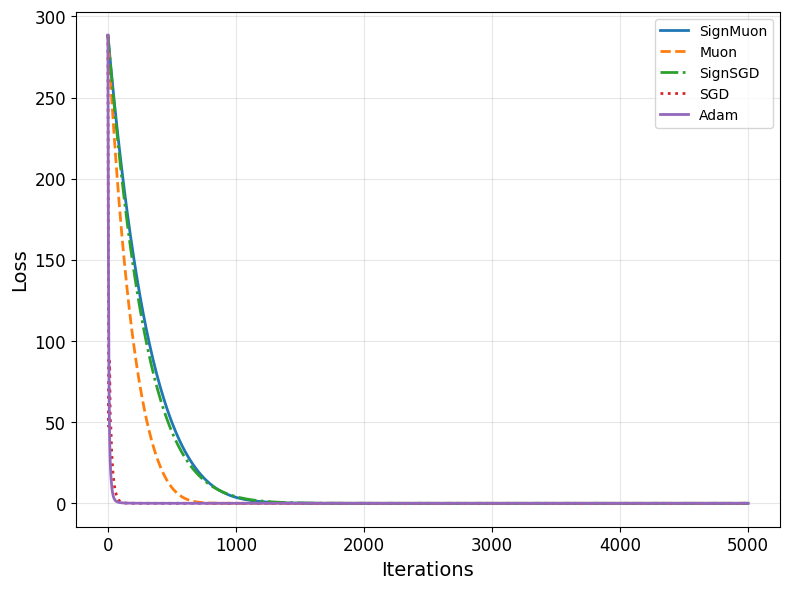

In [66]:
plot_multiple_histories(
    run_dirs=[
        "saves_synthetic/SignMuon",
        "saves_synthetic/Muon",
        "saves_synthetic/SignSGD",
        "saves_synthetic/SGD",
        "saves_synthetic/Adam",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
    ],
    metric="loss_history",
        title="",
    target_loss=0.001,
    max_iterations=5000,
    line_styles=["-", "--", "-.", ":", "-"]
)

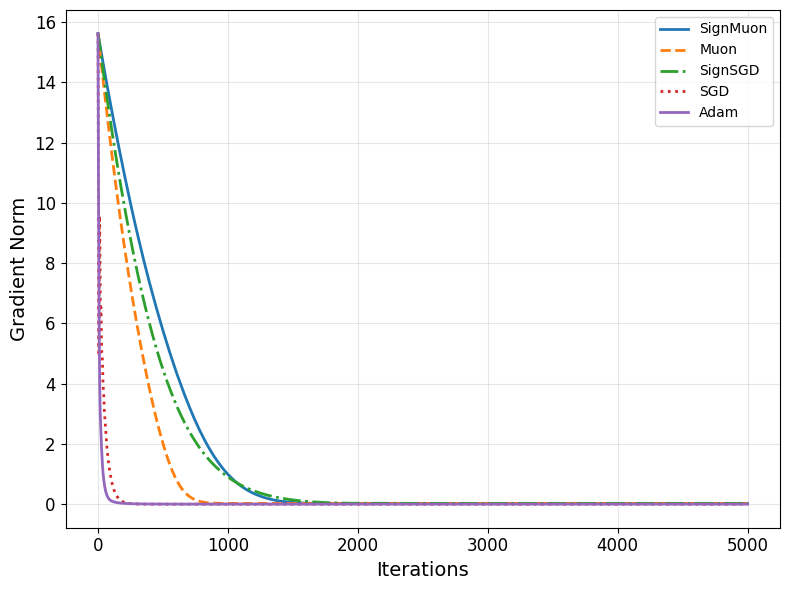

In [67]:
plot_multiple_histories(
    run_dirs=[
        "saves_synthetic/SignMuon",
        "saves_synthetic/Muon",
        "saves_synthetic/SignSGD",
        "saves_synthetic/SGD",
        "saves_synthetic/Adam",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
    ],
    metric="grad_norm_history",
    title="",
    target_loss=0.001,
    max_iterations=5000,
    line_styles=["-", "--", "-.", ":", "-"]
)